## Deep Learning

### Chapter 15: Generative Adverserial Networks

A Generative Adversarial Network (GAN) is a machine learning framework where two neural networks compete against each other to create realistic synthetic data.

Introduced by Ian Goodfellow in 2014, Generative Adversarial Networks consist of a Generator and a Discriminator playing a zero-sum game.

#### 0. Loading the Dataset

In [ ]:
!mkdir celeba_gan

!pip install gdown
!gdown "https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684" -O celeba_gan/data.zip
!unzip -qq celeba_gan/data.zip -d celeba_gan

mkdir: celeba_gan: File exists

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Downloading...
From (original): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684
From (redirected): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684&confirm=t&uuid=2e25eab5-7b98-466d-b99f-6c31635dded1
To: /Users/macbook/Documents/Deep Learning/celeba_gan/data.zip
100%|██████████████████████████████████████| 1.44G/1.44G [01:24<00:00, 17.1MB/s]


### 1. Creating a Dataset from the Images

We can use Keras to automatically load the images from the directory.

In [ ]:
from tensorflow import keras

dataset = keras.utils.image_dataset_from_directory(
    "celeba_gan",
    label_mode=None,
    image_size=(64, 64),
    batch_size=32,
)

Found 202599 files.


### 2. Rescaling the Images

Images normally contain pixel values between **0 and 255**. Neural networks usually work better when the input values are placed in a smaller numerical range.

In [ ]:
dataset = dataset.map(lambda x: x / 255.)

### 3. Displaying the First 10 Images

Before training anything, it is always useful to look at the data.

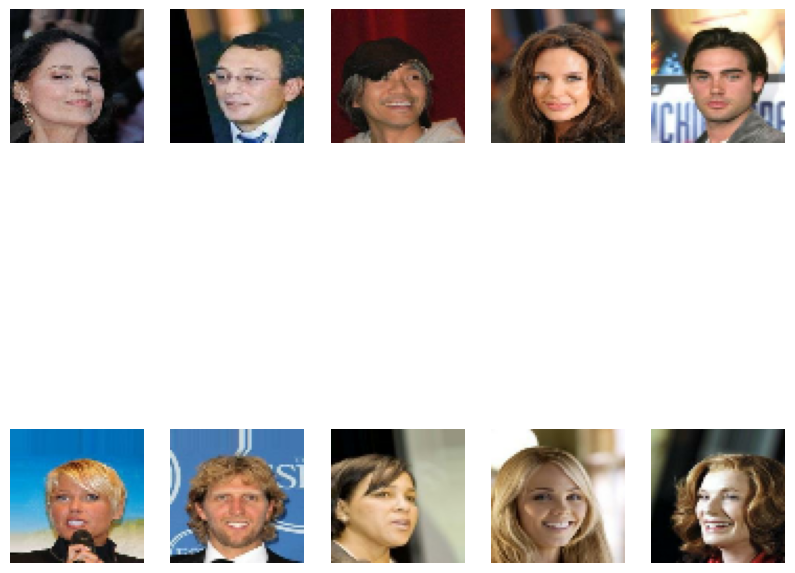

In [ ]:
import matplotlib.pyplot as plt

for x in dataset:
    plt.figure(figsize=(10, 10))

    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x[i].numpy())
        plt.axis("off")

    plt.show()
    break

### 4. The GAN Discriminator Network

The Discriminator is therefore a **classification network**. Its job is to look at an image and produce a prediction indicating whether that image belongs to the real dataset or was generated by the Generator.

Our Discriminator starts with a 64 × 64 RGB image: `64 × 64 × 3` and gradually extracts increasingly useful visual features using convolutional layers.

In [ ]:
from tensorflow.keras import layers

discriminator = keras.Sequential(
    [keras.Input(shape=(64, 64, 3)),
     layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
     layers.LeakyReLU(alpha=0.2),
     layers.Conv2D(128,kernel_size=4, strides=2, padding="same"),
     layers.LeakyReLU(alpha=0.2),
     layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
     layers.LeakyReLU(alpha=0.2),
     layers.Flatten(),
     layers.Dropout(0.2),
     layers.Dense(1, activation="sigmoid"),],
     name="discriminator",
)

discriminator.summary()

/Users/macbook/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,801 (1.54 MB)

 Trainable params: 404,801 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

### 5. The GAN Generator

The **Generator** does not start with an existing face. Instead, we give it a vector of random numbers called a **latent vector**.

For this example, we use: `latent_dim = 128`. That means every generated image starts from a random vector containing **128 values**.

In [ ]:
latent_dim = 128

generator = keras.Sequential([
        keras.Input(shape=(latent_dim,)),
        layers.Dense(8 * 8 * 128),
        layers.Reshape((8, 8, 128)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(512, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(3, kernel_size=5, padding="same", activation="sigmoid"),],
        name="generator",
)

generator.summary()

/Users/macbook/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 256)    │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 512)    │     2,097,664 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 64, 64, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 3)      │        38,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,979,651 (15.18 MB)

 Trainable params: 3,979,651 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

### 7. Training the Adversarial Network

Every training step does two major jobs:

1. Train the Discriminator → Real vs Fake
2. Train the Generator → Make Fake look Real

And then we repeat this process again and again.

In [ ]:
import tensorflow as tf

class GAN(keras.Model):

    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()

        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()

        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self):
        return [self.d_loss_metric,
            self.g_loss_metric]

    def train_step(self, real_images):

        batch_size = tf.shape(real_images)[0]

        # Generate random points in the latent space
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim))

        # Generate fake images
        generated_images = self.generator(
            random_latent_vectors)

        # Combine fake and real images
        combined_images = tf.concat(
            [generated_images, real_images],
            axis=0)

        # 1 = fake, 0 = real
        labels = tf.concat(
            [tf.ones((batch_size, 1)),
             tf.zeros((batch_size, 1))
            ],
            axis=0)

        # Add a small amount of noise to the labels
        labels += 0.05 * tf.random.uniform(
            tf.shape(labels))

        # Train the discriminator
        with tf.GradientTape() as tape:

            predictions = self.discriminator(
                combined_images)

            d_loss = self.loss_fn(
                labels,
                predictions)

        grads = tape.gradient(
            d_loss,
            self.discriminator.trainable_weights)

        self.d_optimizer.apply_gradients(
            zip(grads,
                self.discriminator.trainable_weights)
                )

        # Generate new random points
        random_latent_vectors = tf.random.normal(
            shape=(batch_size, self.latent_dim))

        # Tell the discriminator that all generated
        # images are real
        misleading_labels = tf.zeros(
            (batch_size, 1))

        # Train the generator
        with tf.GradientTape() as tape:

            predictions = self.discriminator(
                self.generator(random_latent_vectors))

            g_loss = self.loss_fn(
                misleading_labels,
                predictions)

        grads = tape.gradient(
            g_loss,
            self.generator.trainable_weights)

        self.g_optimizer.apply_gradients(
            zip(grads, self.generator.trainable_weights))

        # Track both losses
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result()
        }

### 8. Monitoring Generated Images

Loss values are useful, but GANs are a little unusual. A Generator can have a particular loss value without that number telling us exactly what its images look like.

So it is much more useful to periodically save some generated images and watch how they change during training.

At the end of every epoch, the callback generates several new images and saves them.

In [ ]:
class GANMonitor(keras.callbacks.Callback):

    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):

        random_latent_vectors = tf.random.normal(
            shape=(self.num_img, self.latent_dim))

        generated_images = self.model.generator(
            random_latent_vectors)

        generated_images *= 255
        generated_images.numpy()

        for i in range(self.num_img):

            img = keras.utils.array_to_img(
                generated_images[i])

            img.save(f"generated_img_{epoch:03d}_{i}.png")

### 9. Starting the Training

Finally, we can create, compile, and start training our GAN.

In [ ]:
epochs = 100

gan_model = GAN(discriminator=discriminator,
                generator=generator,
                latent_dim=latent_dim)

gan_model.compile(d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                  g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                  loss_fn=keras.losses.BinaryCrossentropy(),)

gan_model.summary()

Model: "gan_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ discriminator (Sequential)      │ (None, 1)              │       404,801 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator (Sequential)          │ (None, 64, 64, 3)      │     3,979,651 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,452 (16.73 MB)

 Trainable params: 4,384,452 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

### Save the model periodically

Add ModelCheckpoint before fit():

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint("gan_checkpoints/gan_epoch_{epoch:03d}.weights.h5",
                                             save_weights_only=True,
                                             save_freq="epoch")

In [ ]:
gan_model.fit(dataset, epochs=epochs,
              callbacks=[GANMonitor(num_img=10, latent_dim=latent_dim)])

### Sample Result

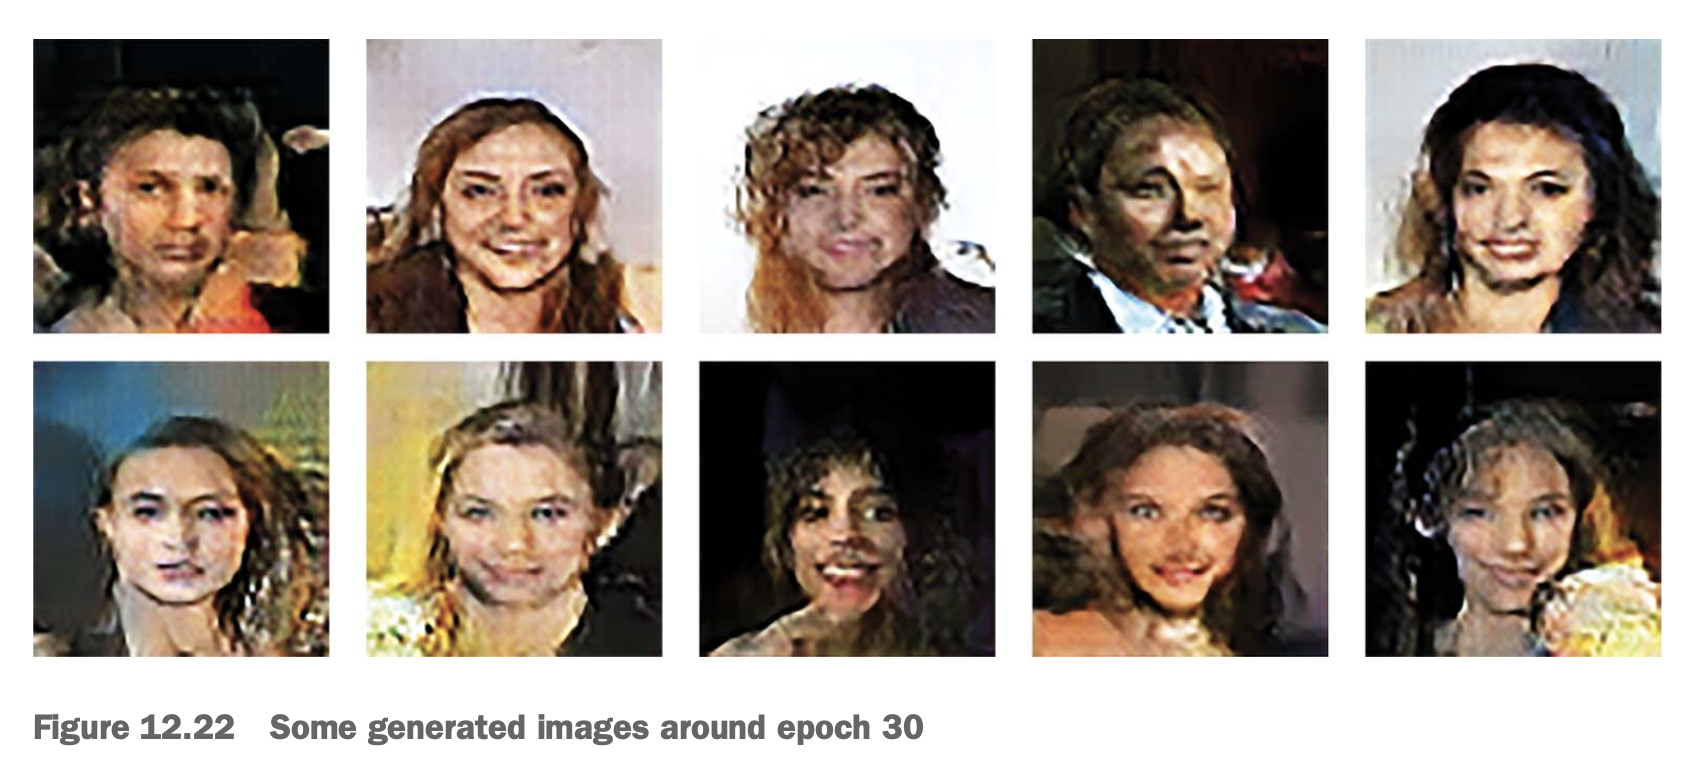